In [320]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix

import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import warnings
warnings.filterwarnings("ignore")

In [321]:
df = pd.read_csv("UFC.csv")
df.head().style.set_sticky(axis="columns")

,event_id,event_name,date,location,fight_id,division,title_fight,method,finish_round,match_time_sec,total_rounds,referee,r_name,r_id,r_kd,r_sig_str_landed,r_sig_str_atmpted,r_sig_str_acc,r_total_str_landed,r_total_str_atmpted,r_total_str_acc,r_td_landed,r_td_atmpted,r_td_acc,r_sub_att,r_ctrl,r_head_landed,r_head_atmpted,r_head_acc,r_body_landed,r_body_atmpted,r_body_acc,r_leg_landed,r_leg_atmpted,r_leg_acc,r_dist_landed,r_dist_atmpted,r_dist_acc,r_clinch_landed,r_clinch_atmpted,r_clinch_acc,r_ground_landed,r_ground_atmpted,r_ground_acc,r_landed_head_per,r_landed_body_per,r_landed_leg_per,r_landed_dist_per,r_landed_clinch_per,r_landed_ground_per,r_nick_name_x,r_wins_x,r_losses_x,r_draws_x,r_height_x,r_weight_x,r_reach_x,r_stance_x,r_dob_x,r_splm_x,r_str_acc_x,r_sapm_x,r_str_def_x,r_td_avg_x,r_td_avg_acc_x,r_td_def_x,r_sub_avg_x,r_nick_name_y,r_wins_y,r_losses_y,r_draws_y,r_height_y,r_weight_y,r_reach_y,r_stance_y,r_dob_y,r_splm_y,r_str_acc_y,r_sapm_y,r_str_def_y,r_td_avg_y,r_td_avg_acc_y,r_td_def_y,r_sub_avg_y,r_nick_name,r_wins,r_losses,r_draws,r_height,r_weight,r_reach,r_stance,r_dob,r_splm,r_str_acc,r_sapm,r_str_def,r_td_avg,r_td_avg_acc,r_td_def,r_sub_avg,b_name,b_id,b_kd,b_sig_str_landed,b_sig_str_atmpted,b_sig_str_acc,b_total_str_landed,b_total_str_atmpted,b_total_str_acc,b_td_landed,b_td_atmpted,b_td_acc,b_sub_att,b_ctrl,b_head_landed,b_head_atmpted,b_head_acc,b_body_landed,b_body_atmpted,b_body_acc,b_leg_landed,b_leg_atmpted,b_leg_acc,b_dist_landed,b_dist_atmpted,b_dist_acc,b_clinch_landed,b_clinch_atmpted,b_clinch_acc,b_ground_landed,b_ground_atmpted,b_ground_acc,b_landed_head_per,b_landed_body_per,b_landed_leg_per,b_landed_dist_per,b_landed_clinch_per,b_landed_ground_per,b_nick_name_x,b_wins_x,b_losses_x,b_draws_x,b_height_x,b_weight_x,b_reach_x,b_stance_x,b_dob_x,b_splm_x,b_str_acc_x,b_sapm_x,b_str_def_x,b_td_avg_x,b_td_avg_acc_x,b_td_def_x,b_sub_avg_x,b_nick_name_y,b_wins_y,b_losses_y,b_draws_y,b_height_y,b_weight_y,b_reach_y,b_stance_y,b_dob_y,b_splm_y,b_str_acc_y,b_sapm_y,b_str_def_y,b_td_avg_y,b_td_avg_acc_y,b_td_def_y,b_sub_avg_y,b_nick_name,b_wins,b_losses,b_draws,b_height,b_weight,b_reach,b_stance,b_dob,b_splm,b_str_acc,b_sapm,b_str_def,b_td_avg,b_td_avg_acc,b_td_def,b_sub_avg,winner,winner_id
0,872b018076f831b0,UFC Fight Night: Della Maddalena vs. Prates,2026-05-02,"Perth, Western Australia, Australia",5c7c38dece435cde,lightweight,0,KO/TKO,1,209,3.000000,Rich Mitchell,Beneil Dariush,08af939f41b5a57b,0.000000,3.000000,9.000000,33.000000,4.000000,10.000000,40.000000,2.000000,5.000000,40.000000,0.000000,152.000000,2.000000,7.000000,28.000000,0.000000,1.000000,0.000000,1.000000,1.000000,100.000000,3.000000,7.000000,43.000000,0.000000,2.000000,0.000000,0.000000,0.000000,nan,66.000000,0.000000,33.000000,100.000000,0.000000,0.000000,nan,23,8,1,177.800000,70.310000,182.880000,Southpaw,"May 06, 1989",3.740000,49,2.630000,57,2.210000,38,82,0.800000,nan,23,8,1,177.800000,70.310000,182.880000,Southpaw,"May 06, 1989",3.740000,49,2.630000,57,2.210000,38,82,0.800000,nan,23,8,1,177.800000,70.310000,182.880000,Southpaw,1989-05-06,3.740000,49,2.630000,57,2.210000,38,82,0.800000,Quillan Salkilld,17734443a833cdf7,1.000000,12.000000,19.000000,63.000000,15.000000,24.000000,62.000000,0.000000,2.000000,0.000000,0.000000,20.000000,11.000000,18.000000,61.000000,1.000000,1.000000,100.000000,0.000000,0.000000,nan,7.000000,13.000000,54.000000,2.000000,3.000000,67.000000,3.000000,3.000000,100.000000,91.000000,8.000000,0.000000,58.000000,16.000000,25.000000,nan,12,1,0,182.880000,70.310000,190.500000,Orthodox,"Dec 28, 1999",5.010000,57,3.030000,45,7.250000,35,80,0.800000,nan,12,1,0,182.880000,70.310000,190.500000,Orthodox,"Dec 28, 1999",5.010000,57,3.030000,45,7.250000,35,80,0.800000,nan,12,1,0,182.880000,70.310000,190.500000,Orthodox,1999-12-28,5.010000,57,3.030000,45,7.250000,35,80,0.800000,Quillan Salkilld,17734443a833cdf7
1,872b018076f831b0,UFC Fight Night: Della Maddalena vs. Prates,2026-05-02,"Perth, Western Australia, Australia",eb6d

In [322]:
cols = [
    'method',
    'date', 'r_dob_x', 'b_dob_y',
    # fighter names
    'r_name', 'b_name',
    # striking volume
    'r_splm_x', 'b_splm_y',
    # strikes absorbed
    'r_sapm_x', 'b_sapm_y',
    # striking accuracy
    'r_str_acc_x', 'b_str_acc_y',
    # striking defense
    'r_str_def_x', 'b_str_def_y',
    # takedowns landed,
    'r_td_avg_x', 'b_td_avg_y',
    # takedown accuracy
    'r_td_avg_acc_x', 'b_td_avg_acc_y',
    # takedown defense
    'r_td_def_x', 'b_td_def_y',
    # submission attempts
    'r_sub_avg_x', 'b_sub_avg_y',
    # reach
    'r_reach', 'b_reach',
    # height
    'r_height', 'b_height',
    # weight
    'r_weight_x',
    # winner name
    'winner',
    # wins and losses
    'r_wins', 'b_wins', 'r_losses', 'b_losses'
]

# to add -> str defense, td defense, height, win% diff

df = df[cols].copy()

# create column 'winner_corner' = 1 if Red won, 0 if Blue won
df['winner_corner'] = np.where(df['winner'] == df['r_name'], 1, 0)

In [323]:
# fill missing numeric values with mean
numeric_cols = [
    'r_splm_x', 'b_splm_y',
    'r_sapm_x', 'b_sapm_y',
    'r_str_acc_x', 'b_str_acc_y',
    'r_str_def_x', 'b_str_def_y',
    'r_td_avg_x', 'b_td_avg_y',
    'r_td_avg_acc_x', 'b_td_avg_acc_y',
    'r_td_def_x', 'b_td_def_y',
    'r_sub_avg_x', 'b_sub_avg_y',
    'r_reach', 'b_reach',
    'r_height', 'b_height',
    'r_weight_x',
    'r_wins', 'b_wins', 'r_losses', 'b_losses'
]

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

In [324]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by="date")
df["r_dob_x"] = pd.to_datetime(
    df["r_dob_x"],
    errors="coerce",
    format="mixed"
)

df["b_dob_y"] = pd.to_datetime(
    df["b_dob_y"],
    errors="coerce",
    format="mixed"
)

In [325]:
df.head()

,method,date,r_dob_x,b_dob_y,r_name,b_name,r_splm_x,b_splm_y,r_sapm_x,b_sapm_y,...,b_reach,r_height,b_height,r_weight_x,winner,r_wins,b_wins,r_losses,b_losses,winner_corner
8656,Submission,1994-03-11,1966-12-12,1969-05-23,Royce Gracie,Remco Pardoel,0.88,0.0,1.13,0.0,...,182.663051,185.42,190.50,79.38,Royce Gracie,15,9,2,6,1
8654,KO/TKO,1994-03-11,1966-12-12,1963-08-28,Royce Gracie,Patrick Smith,0.88,0.0,1.13,0.0,...,182.663051,185.42,187.96,79.38,Royce Gracie,15,20,2,17,1
8655,Submission,1994-03-11,1963-08-28,NaT,Patrick Smith,Johnny Rhodes,0.00,0.0,0.00,0.0,...,182.663051,187.96,182.88,102.06,Patrick Smith,20,2,17,1,1
8669,Submission,1994-03-11,NaT,1975-12-04,Scott Morris,Sean Daugherty,0.00,0.0,0.00,0.0,...,182.663051,177.80,182.88,95.25,Scott Morris,2,0,1,2,1
8657,KO/TKO,1994-03-11,1969-05-23,1965-10-24,Remco Pardoel,Orlando Wiet,0.00,0.0,0.00,0.0,...,182.663051,190.50,177.80,117.93,Remco Pardoel,9,1,6,5,1


In [326]:
# Age at fight
df["r_age"] = (
    (df["date"] - df["r_dob_x"]).dt.days / 365.25
)

df["b_age"] = (
    (df["date"] - df["b_dob_y"]).dt.days / 365.25
)    

In [327]:
df = df.sort_values(by='date')

<h1>Momentum Features</h1>

In [328]:
# red fighter history
red_df = pd.DataFrame({
    "fighter": df["r_name"],
    "date": df["date"],
    "method": df["method"],
    "win": np.where(df["winner"] == df["r_name"], 1, 0)
})

# blue fighter history
blue_df = pd.DataFrame({
    "fighter": df["b_name"],
    "date": df["date"],
    "method": df["method"],
    "win": np.where(df["winner"] == df["b_name"], 1, 0)
})

# combine together
fighter_history = pd.concat([red_df, blue_df], ignore_index=True)

# sort chronologically
fighter_history = fighter_history.sort_values(by="date")


fighter_history["ko_win"] = np.where(
    (fighter_history["win"] == 1) &
    (fighter_history["method"].str.contains("KO", case=False, na=False)),
    1,
    0
)

fighter_history["ko_loss"] = np.where(
    (fighter_history["win"] == 0) &
    (fighter_history["method"].str.contains("KO", case=False, na=False)),
    1,
    0
)

fighter_history["sub_win"] = np.where(
    (fighter_history["win"] == 1) &
    (fighter_history["method"].str.contains("Sub", case=False, na=False)),
    1,
    0
)

fighter_history["sub_loss"] = np.where(
    (fighter_history["win"] == 0) &
    (fighter_history["method"].str.contains("Sub", case=False, na=False)),
    1,
    0
)

fighter_history["dec_win"] = np.where(
    (fighter_history["win"] == 1) &
    (fighter_history["method"].str.contains("Decision", case=False, na=False)),
    1,
    0
)

fighter_history["dec_loss"] = np.where(
    (fighter_history["win"] == 0) &
    (fighter_history["method"].str.contains("Decision", case=False, na=False)),
    1,
    0
)

career_cols = [
    "ko_win",
    "ko_loss",
    "sub_win",
    "sub_loss",
    "dec_win",
    "dec_loss"
]

for col in career_cols:
    fighter_history[f"total_{col}"] = (
        fighter_history
        .groupby("fighter")[col]
        .transform(lambda x: x.cumsum().shift(1))
    )

total_cols = [f"total_{col}" for col in career_cols]
fighter_history[total_cols] = fighter_history[total_cols].fillna(0)

In [329]:
fighter_history["last_3_wins"] = (
    fighter_history
    .groupby("fighter")["win"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).sum())
)

fighter_history["last_6_wins"] = (
    fighter_history
    .groupby("fighter")["win"]
    .transform(lambda x: x.shift(1).rolling(6, min_periods=1).sum())
)

fighter_history["last_3_wins"] = fighter_history["last_3_wins"].fillna(0)
fighter_history["last_6_wins"] = fighter_history["last_6_wins"].fillna(0)

<h1>Activity/ Experience</h1>

In [330]:
# Total UFC experience
fighter_history["ufc_fights_before"] = (
    fighter_history
    .groupby("fighter")
    .cumcount()
)

# Recent Activity
fighter_history["date"] = pd.to_datetime(fighter_history["date"])
fighter_history["days_since_last_fight"] = (
    fighter_history
    .groupby("fighter")["date"]
    .diff()
    .dt.days
)

fighter_history["days_since_last_fight"] = (
    fighter_history["days_since_last_fight"].fillna(365)
)

<h1>Elo System</h1>

In [331]:
fighter_elo = {}
K = 32  # how fast ratings change

import math

def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

df = df.sort_values("date").reset_index(drop=True)

# split before Elo so test fights don't influence training ratings
cutoff_raw = int(len(df) * 0.8)
train_df = df.iloc[:cutoff_raw].copy()
test_df  = df.iloc[cutoff_raw:].copy()

r_elo = []
b_elo = []

for _, row in train_df.iterrows():

    r = row["r_name"]
    b = row["b_name"]

    # default rating
    r_rating = fighter_elo.get(r, 1500)
    b_rating = fighter_elo.get(b, 1500)

    # store current ratings as features
    r_elo.append(r_rating)
    b_elo.append(b_rating)

    # expected scores
    r_exp = expected_score(r_rating, b_rating)
    b_exp = 1 - r_exp

    # actual outcome
    r_score = 1 if row["winner_corner"] == 1 else 0
    b_score = 1 - r_score

    # update ratings
    fighter_elo[r] = r_rating + K * (r_score - r_exp)
    fighter_elo[b] = b_rating + K * (b_score - b_exp)

train_df["r_elo"] = r_elo
train_df["b_elo"] = b_elo

# test fighters get their frozen Elo from end of training
test_df["r_elo"] = [fighter_elo.get(r, 1500) for r in test_df["r_name"]]
test_df["b_elo"] = [fighter_elo.get(b, 1500) for b in test_df["b_name"]]

df = pd.concat([train_df, test_df]).sort_values("date").reset_index(drop=True)
df["elo_diff"] = df["r_elo"] - df["b_elo"]

In [332]:
# weighted wins

elo_lookup_r = df[["date", "r_name", "r_elo"]].rename(columns={
    "r_name": "fighter",
    "r_elo": "opp_elo"
})

elo_lookup_b = df[["date", "b_name", "b_elo"]].rename(columns={
    "b_name": "fighter",
    "b_elo": "opp_elo"
})

elo_lookup = pd.concat([elo_lookup_r, elo_lookup_b])

fighter_history = fighter_history.merge(
    elo_lookup,
    on=["fighter", "date"],
    how="left"
)

fighter_history["weighted_win"] = fighter_history["win"] * fighter_history["opp_elo"]
fighter_history["weighted_loss"] = (1 - fighter_history["win"]) * fighter_history["opp_elo"]

fighter_history["quality_last_3"] = (
    fighter_history
    .groupby("fighter")["weighted_win"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).sum())
)

fighter_history["quality_last_6"] = (
    fighter_history
    .groupby("fighter")["weighted_win"]
    .transform(lambda x: x.shift(1).rolling(6, min_periods=1).sum())
)

# Merge

<h1>Merge</h1>

In [333]:
# NAME + DATE ALIGN
df["r_name"] = df["r_name"].str.strip().str.lower()
df["b_name"] = df["b_name"].str.strip().str.lower()
fighter_history["fighter"] = fighter_history["fighter"].str.strip().str.lower()

df["date"] = pd.to_datetime(df["date"])
fighter_history["date"] = pd.to_datetime(fighter_history["date"])

# sort data for time-based merging
df = df.sort_values("date")
fighter_history = fighter_history.sort_values("date")


# RED FEATURES
red_features = fighter_history.copy()

red_features = red_features.rename(columns={
    "fighter": "r_name",
    "last_3_wins": "r_last_3_wins",
    "last_6_wins": "r_last_6_wins",

    "total_ko_win": "r_total_ko_win",
    "total_ko_loss": "r_total_ko_loss",
    "total_sub_win": "r_total_sub_win",
    "total_sub_loss": "r_total_sub_loss",
    "total_dec_win": "r_total_dec_win",
    "total_dec_loss": "r_total_dec_loss",

    "ufc_fights_before": "r_ufc_fights_before",
    "days_since_last_fight": "r_days_since_last_fight",

    # QUALITY FEATURES (NEW)
    "quality_last_3": "r_quality_last_3",
    "quality_last_6": "r_quality_last_6"
})


# BLUE FEATURES
blue_features = fighter_history.copy()

blue_features = blue_features.rename(columns={
    "fighter": "b_name",
    "last_3_wins": "b_last_3_wins",
    "last_6_wins": "b_last_6_wins",

    "total_ko_win": "b_total_ko_win",
    "total_ko_loss": "b_total_ko_loss",
    "total_sub_win": "b_total_sub_win",
    "total_sub_loss": "b_total_sub_loss",
    "total_dec_win": "b_total_dec_win",
    "total_dec_loss": "b_total_dec_loss",

    "ufc_fights_before": "b_ufc_fights_before",
    "days_since_last_fight": "b_days_since_last_fight",

    # QUALITY FEATURES (NEW)
    "quality_last_3": "b_quality_last_3",
    "quality_last_6": "b_quality_last_6"
})

df = df.drop_duplicates(["r_name", "b_name", "date"])
fighter_history = fighter_history.drop_duplicates(["fighter", "date"])

# merge red fighter historical stats (only past data)
df = pd.merge_asof(
    df.sort_values("date"),
    red_features.sort_values("date"),
    by="r_name",
    on="date",
    direction="backward"
)


# merge blue fighter historical stats (only past data)
df = pd.merge_asof(
    df.sort_values("date"),
    blue_features.sort_values("date"),
    by="b_name",
    on="date",
    direction="backward"
)


# columns to clean missing values
new_cols = [

    # RED
    "r_last_3_wins",
    "r_last_6_wins",
    "r_total_ko_win",
    "r_total_ko_loss",
    "r_total_sub_win",
    "r_total_sub_loss",
    "r_total_dec_win",
    "r_total_dec_loss",
    "r_ufc_fights_before",
    "r_days_since_last_fight",
    "r_quality_last_3",
    "r_quality_last_6",

    # BLUE
    "b_last_3_wins",
    "b_last_6_wins",
    "b_total_ko_win",
    "b_total_ko_loss",
    "b_total_sub_win",
    "b_total_sub_loss",
    "b_total_dec_win",
    "b_total_dec_loss",
    "b_ufc_fights_before",
    "b_days_since_last_fight",
    "b_quality_last_3",
    "b_quality_last_6"
]

# fill missing values with 0
df[new_cols] = df[new_cols].fillna(0)

# fill missing elo

fighter_history["opp_elo"] = fighter_history["opp_elo"].fillna(1500)

In [334]:
df.sort_values(by='date', ascending=False).head().style.set_sticky(axis="columns")

,method_x,date,r_dob_x,b_dob_y,r_name,b_name,r_splm_x,b_splm_y,r_sapm_x,b_sapm_y,r_str_acc_x,b_str_acc_y,r_str_def_x,b_str_def_y,r_td_avg_x,b_td_avg_y,r_td_avg_acc_x,b_td_avg_acc_y,r_td_def_x,b_td_def_y,r_sub_avg_x,b_sub_avg_y,r_reach,b_reach,r_height,b_height,r_weight_x,winner,r_wins,b_wins,r_losses,b_losses,winner_corner,r_age,b_age,r_elo,b_elo,elo_diff,method_y,win_x,ko_win_x,ko_loss_x,sub_win_x,sub_loss_x,dec_win_x,dec_loss_x,r_total_ko_win,r_total_ko_loss,r_total_sub_win,r_total_sub_loss,r_total_dec_win,r_total_dec_loss,r_last_3_wins,r_last_6_wins,r_ufc_fights_before,r_days_since_last_fight,opp_elo_x,weighted_win_x,weighted_loss_x,r_quality_last_3,r_quality_last_6,method,win_y,ko_win_y,ko_loss_y,sub_win_y,sub_loss_y,dec_win_y,dec_loss_y,b_total_ko_win,b_total_ko_loss,b_total_sub_win,b_total_sub_loss,b_total_dec_win,b_total_dec_loss,b_last_3_wins,b_last_6_wins,b_ufc_fights_before,b_days_since_last_fight,opp_elo_y,weighted_win_y,weighted_loss_y,b_quality_last_3,b_quality_last_6
8673,KO/TKO,2026-05-02 00:00:00,1989-05-06 00:00:00,1999-12-28 00:00:00,beneil dariush,quillan salkilld,3.740000,5.010000,2.630000,3.030000,49,57,57,45,2.210000,7.250000,38,35,82,80,0.800000,0.800000,182.880000,190.500000,177.800000,182.880000,70.310000,Quillan Salkilld,23,12,8,1,0,36.988364,26.343600,1661.689351,1500.000000,161.689351,KO/TKO,0,0,1,0,0,0,0,3.000000,6.000000,5.000000,1.000000,9.000000,1.000000,1.000000,3.000000,25,168.000000,1661.689351,0.000000,1661.689351,1661.689351,4944.398153,KO/TKO,1,1,0,0,0,0,0,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,4.000000,4,91.000000,1500.000000,1500.000000,0.000000,4500.000000,6000.000000
8667,KO/TKO,2026-05-02 00:00:00,1996-09-21 00:00:00,1995-01-21 00:00:00,junior tafa,kevin christian,3.620000,2.190000,2.660000,3.540000,53,58,51,40,0.000000,0.000000,0,0,72,50,0.000000,1.900000,190.500000,203.200000,190.500000,200.660000,92.990000,Junior Tafa,7,9,5,4,1,29.609856,31.277207,1500.000000,1500.000000,0.000000,KO/TKO,1,1,0,0,0,0,0,2.000000,1.000000,0.000000,3.000000,0.000000,1.000000,1.000000,2.000000,7,91.000000,1500.000000,1500.000000,0.000000,1500.000000,3000.000000,KO/TKO,0,0,1,0,0,0,0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1,182.000000,1500.000000,0.000000,1500.000000,0.000000,0.000000
8661,KO/TKO,2026-05-02 00:00:00,2002-05-10 00:00:00,2000-12-28 00:00:00,marwan rahiki,ollie schmid,7.750000,3.230000,5.900000,7.900000,52,30,57,45,0.000000,0.000000,0,0,100,0,0.800000,0.000000,182.880000,180.340000,172.720000,182.880000,65.770000,Marwan Rahiki,9,4,0,3,1,23.978097,25.341547,1500.000000,1500.000000,0.000000,KO/TKO,1,1,0,0,0,0,0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1,49.000000,1500.000000,1500.000000,0.000000,1500.000000,1500.000000,KO/TKO,0,0,1,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,365.000000,1500.000000,0.000000,1500.000000,0.000000,0.000000
8662,KO/TKO,2026-05-02 00:00:00,1990-02-10 00:00:00,1994-08-03 00:00:00,shamil gaziev,brando pericic,2.940000,11.000000,4.920000,4.260000,46,57,45,58,1.060000,0.000000,33,0,83,71,0.300000,0.000000,198.120000,200.660000,193.040000,195.580000,120.200000,Brando Pericic,14,7,3,1,0,36.221766,31.745380,1500.000000,1500.000000,0.000000,KO/TKO,0,0,1,0,0,0,0,2.000000,2.000000,0.000000,0.000000,1.000000,0.000000,2.000000,3.000000,5,161.000000,1500.000000,0.000000,1500.000000,3000.000000,4500.000000,KO/TKO,1,1,0,0,0,0,0,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,2,42.000000,1500.000000,1500.000000,0.000000,3000.000000,3000.000000
8663,Decision - Unanimous,2026-05-02 00:00:00,1995-01-19 00:00:00,1990-07-04 00:00:00,cam rowston,robert bryczek,4.600000,2.800000,2.120000,4.510000,48,37,52,55,1.340000,0.360000,44,100,33,71,0.300000,0.400000,198.120000,190.500000,190.500000,182.880000,83.910000,Cam Rowston,15,18,3,7,1,31.282683,35.827515,1500.000000,1500.000000,0.000000,Decision - Unanimous,1,0,0,0,0,1,0,2.000000,0.000000,0.000

In [335]:

# RATE-BASED FEATURES 

# win rate (core improvement over raw wins/losses)
df["r_fight_total"] = (df["r_wins"] + df["r_losses"]).replace(0, np.nan)
df["b_fight_total"] = (df["b_wins"] + df["b_losses"]).replace(0, np.nan)

df["r_win_rate"] = df["r_wins"] / df["r_fight_total"]
df["b_win_rate"] = df["b_wins"] / df["b_fight_total"]

df["r_win_rate"] = df["r_win_rate"].fillna(0)
df["b_win_rate"] = df["b_win_rate"].fillna(0)


# MOMENTUM → RATE FEATURES

df["r_total_fights"] = df["r_ufc_fights_before"].replace(0, np.nan)
df["b_total_fights"] = df["b_ufc_fights_before"].replace(0, np.nan)

# win momentum rate (better than raw rolling sums)
df["r_momentum_3_rate"] = df["r_last_3_wins"] / 3
df["b_momentum_3_rate"] = df["b_last_3_wins"] / 3

df["r_momentum_6_rate"] = df["r_last_6_wins"] / 6
df["b_momentum_6_rate"] = df["b_last_6_wins"] / 6

# QUALITY FEATURES → NORMALIZED

df["r_quality_3_rate"] = df["r_quality_last_3"] / 3
df["b_quality_3_rate"] = df["b_quality_last_3"] / 3

df["r_quality_6_rate"] = df["r_quality_last_6"] / 6
df["b_quality_6_rate"] = df["b_quality_last_6"] / 6

# CORE DIFFERENCE FEATURES (WHAT MODEL SHOULD ACTUALLY USE)

df["win_rate_diff"] = df["r_win_rate"] - df["b_win_rate"]

df["momentum_3_diff"] = df["r_momentum_3_rate"] - df["b_momentum_3_rate"]
df["momentum_6_diff"] = df["r_momentum_6_rate"] - df["b_momentum_6_rate"]

df["quality_3_diff"] = df["r_quality_3_rate"] - df["b_quality_3_rate"]
df["quality_6_diff"] = df["r_quality_6_rate"] - df["b_quality_6_rate"]

df["experience_diff"] = df["r_ufc_fights_before"] - df["b_ufc_fights_before"]

<h1>Fix Corner Bias</h1>

In [336]:
# =========================
# CORNER FLIP 
# =========================

df_base = df.copy().sort_values("date").reset_index(drop=True)
df_flip = df.copy().sort_values("date").reset_index(drop=True)

# -------------------------
# 1. swap identity columns
# -------------------------
df_flip[["r_name", "b_name"]] = df_flip[["b_name", "r_name"]].values
df_flip[["r_age", "b_age"]] = df_flip[["b_age", "r_age"]].values
df_flip[["r_reach", "b_reach"]] = df_flip[["b_reach", "r_reach"]].values
df_flip[["r_height", "b_height"]] = df_flip[["b_height", "r_height"]].values

# -------------------------
# 2. swap Elo
# -------------------------
df_flip[["r_elo", "b_elo"]] = df_flip[["b_elo", "r_elo"]].values

# -------------------------
# 3. swap directional features
# -------------------------

swap_map = {
    "striking_volume":  ("r_splm_x",          "b_splm_y"),
    "striking_absorbed":("r_sapm_x",           "b_sapm_y"),
    "striking_acc":     ("r_str_acc_x",        "b_str_acc_y"),
    "striking_def":     ("r_str_def_x",        "b_str_def_y"),
    "td_avg":           ("r_td_avg_x",         "b_td_avg_y"),
    "td_acc":           ("r_td_avg_acc_x",     "b_td_avg_acc_y"),
    "td_def":           ("r_td_def_x",         "b_td_def_y"),
    "sub_avg":          ("r_sub_avg_x",        "b_sub_avg_y"),
    "wins":             ("r_wins",             "b_wins"),
    "losses":           ("r_losses",           "b_losses"),
    "win_rate":         ("r_win_rate",         "b_win_rate"),
    "last_3_wins":      ("r_last_3_wins",      "b_last_3_wins"),
    "last_6_wins":      ("r_last_6_wins",      "b_last_6_wins"),
    "ko_win":           ("r_total_ko_win",     "b_total_ko_win"),
    "ko_loss":          ("r_total_ko_loss",    "b_total_ko_loss"),
    "sub_win":          ("r_total_sub_win",    "b_total_sub_win"),
    "sub_loss":         ("r_total_sub_loss",   "b_total_sub_loss"),
    "dec_win":          ("r_total_dec_win",    "b_total_dec_win"),
    "dec_loss":         ("r_total_dec_loss",   "b_total_dec_loss"),
    "ufc_fights":       ("r_ufc_fights_before","b_ufc_fights_before"),
    "days_since":       ("r_days_since_last_fight", "b_days_since_last_fight"),
    "quality_3":        ("r_quality_last_3",   "b_quality_last_3"),
    "quality_6":        ("r_quality_last_6",   "b_quality_last_6"),
}

for _, (r_col, b_col) in swap_map.items():
    df_flip[[r_col, b_col]] = df_flip[[b_col, r_col]].values

# -------------------------
# 4. flip label
# -------------------------
df_flip["winner_corner"] = 1 - df_flip["winner_corner"]

# -------------------------
# 5. split THEN combine — flip only training data
# -------------------------
cutoff_raw = int(len(df_base) * 0.8)
train_base = df_base.iloc[:cutoff_raw]
test_clean = df_base.iloc[cutoff_raw:]

train_flip = df_flip.iloc[:cutoff_raw]

train_balanced = pd.concat([train_base, train_flip], ignore_index=True)

df_balanced = pd.concat([train_balanced, test_clean], ignore_index=True)

# -------------------------
# 6. re-sort after concat
# -------------------------
df_balanced = df_balanced.sort_values("date").reset_index(drop=True)

<h1>Final Model Feature Input</h1>

In [337]:
# final model input
df_model = df_balanced.copy()

# physical diffs
df_model["age_diff"] = df_model["r_age"] - df_model["b_age"]
df_model["reach_diff"] = df_model["r_reach"] - df_model["b_reach"]
df_model["height_diff"] = df_model["r_height"] - df_model["b_height"]
df_model["weight_class"] = df_model["r_weight_x"]

# striking diffs
df_model["str_volume_diff"] = df_model["r_splm_x"] - df_model["b_splm_y"]
df_model["str_acc_diff"] = df_model["r_str_acc_x"] - df_model["b_str_acc_y"]
df_model["str_def_diff"] = df_model["r_str_def_x"] - df_model["b_str_def_y"]
df_model["sapm_diff"] = df_model["r_sapm_x"] - df_model["b_sapm_y"]

# grappling diffs
df_model["td_volume_diff"] = df_model["r_td_avg_x"] - df_model["b_td_avg_y"]
df_model["td_acc_diff"] = df_model["r_td_avg_acc_x"] - df_model["b_td_avg_acc_y"]
df_model["td_def_diff"] = df_model["r_td_def_x"] - df_model["b_td_def_y"]
df_model["sub_diff"] = df_model["r_sub_avg_x"] - df_model["b_sub_avg_y"]

# win rate
df_model["r_win_rate"] = df_model["r_wins"] / (df_model["r_wins"] + df_model["r_losses"] + 1e-6)
df_model["b_win_rate"] = df_model["b_wins"] / (df_model["b_wins"] + df_model["b_losses"] + 1e-6)
df_model["win_rate_diff"] = df_model["r_win_rate"] - df_model["b_win_rate"]

# experience
df_model["fights_diff"] = df_model["r_ufc_fights_before"] - df_model["b_ufc_fights_before"]
df_model["rest_diff"] = df_model["r_days_since_last_fight"] - df_model["b_days_since_last_fight"]

# momentum
df_model["r_momentum_3"] = df_model["r_last_3_wins"] / 3
df_model["b_momentum_3"] = df_model["b_last_3_wins"] / 3
df_model["r_momentum_6"] = df_model["r_last_6_wins"] / 6
df_model["b_momentum_6"] = df_model["b_last_6_wins"] / 6

df_model["momentum_3_diff"] = df_model["r_momentum_3"] - df_model["b_momentum_3"]
df_model["momentum_6_diff"] = df_model["r_momentum_6"] - df_model["b_momentum_6"]

# quality
df_model["r_quality_3"] = df_model["r_quality_last_3"] / 3
df_model["b_quality_3"] = df_model["b_quality_last_3"] / 3
df_model["r_quality_6"] = df_model["r_quality_last_6"] / 6
df_model["b_quality_6"] = df_model["b_quality_last_6"] / 6

df_model["quality_3_diff"] = df_model["r_quality_3"] - df_model["b_quality_3"]
df_model["quality_6_diff"] = df_model["r_quality_6"] - df_model["b_quality_6"]

# elo
df_model["elo_diff"] = df_model["r_elo"] - df_model["b_elo"]

# drop raw features
df_model = df_model[[col for col in df_model.columns if not col.startswith("r_") and not col.startswith("b_")]]

df_model.head()

,method_x,date,winner,winner_corner,elo_diff,method_y,win_x,ko_win_x,ko_loss_x,sub_win_x,...,str_volume_diff,str_acc_diff,str_def_diff,sapm_diff,td_volume_diff,td_acc_diff,td_def_diff,sub_diff,fights_diff,rest_diff
0,Submission,1994-03-11,Royce Gracie,1,0.000000,KO/TKO,1,1,0,0,...,0.88,41,37,1.13,0.0,0,66,0.8,0,0.0
1,KO/TKO,1994-03-11,Orlando Wiet,0,16.736307,KO/TKO,1,1,0,0,...,0.00,0,0,0.00,0.0,0,0,0.0,-1,365.0
2,Submission,1994-03-11,Remco Pardoel,0,-0.736307,KO/TKO,1,1,0,0,...,0.00,0,0,0.00,0.0,0,0,0.0,-2,365.0
3,Submission,1994-03-11,Royce Gracie,0,-29.827820,KO/TKO,1,1,0,0,...,-0.88,-41,-37,-1.13,0.0,0,-66,-0.8,-1,0.0
4,Submission,1994-03-11,Johnny Rhodes,0,1.435873,Submission,1,0,0,1,...,0.00,0,0,0.00,0.0,0,0,0.0,-2,365.0


In [338]:
features = [
    # physical
    "age_diff",
    "reach_diff",
    "height_diff",
    "weight_class",

    # striking
    "str_volume_diff",
    "str_acc_diff",
    "str_def_diff",
    "sapm_diff",

    # grappling
    "td_volume_diff",
    "td_acc_diff",
    "td_def_diff",
    "sub_diff",

    # experience
    "fights_diff",
    "rest_diff",

    # momentum
    "momentum_3_diff",
    "momentum_6_diff",

    # quality
    "quality_3_diff",
    "quality_6_diff",

    # win strength
    "win_rate_diff",

    # elo (very important)
    "elo_diff"
]

<h1>Model Build</h1>

In [339]:
df_model = df_model.sort_values("date").reset_index(drop=True)

# training set is 2x cutoff_raw due to flip augmentation, test is untouched
cutoff = cutoff_raw * 2

train = df_model.iloc[:cutoff]
test = df_model.iloc[cutoff:]

X_train = train[features]
y_train = train["winner_corner"]

X_test = test[features]
y_test = test["winner_corner"]

model = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    min_child_weight=4,
    gamma=0.2
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [340]:
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, preds))
print("Log loss:", log_loss(y_test, probs))
print("\nReport:\n", classification_report(y_test, preds))
print("\nConfusion matrix:\n", confusion_matrix(y_test, preds))

Accuracy: 0.7412103746397695
Log loss: 0.5319152781237684

Report:
               precision    recall  f1-score   support

           0       0.71      0.73      0.72       791
           1       0.77      0.75      0.76       944

    accuracy                           0.74      1735
   macro avg       0.74      0.74      0.74      1735
weighted avg       0.74      0.74      0.74      1735


Confusion matrix:
 [[579 212]
 [237 707]]


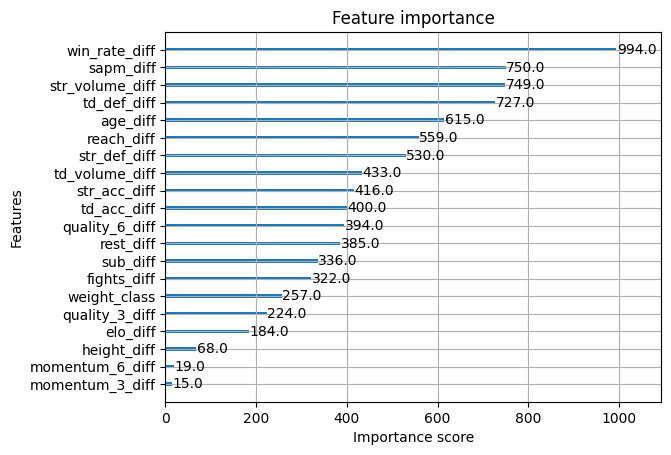

In [ ]:
xgb.plot_importance(model)
plt.show()

In [346]:
importance = model.get_booster().get_score(importance_type="gain")

importance_df = pd.DataFrame({
    "feature": list(importance.keys()),
    "importance": list(importance.values())
}).sort_values("importance", ascending=False)

importance_df["importance"] /= importance_df["importance"].sum()
importance_df = importance_df.sort_values("importance", ascending=False)

print(importance_df)

            feature  importance
18    win_rate_diff    0.158736
4   str_volume_diff    0.128763
10      td_def_diff    0.066109
17   quality_6_diff    0.054286
6      str_def_diff    0.053889
7         sapm_diff    0.049920
8    td_volume_diff    0.048848
5      str_acc_diff    0.048674
1        reach_diff    0.045652
13        rest_diff    0.045371
15  momentum_6_diff    0.043213
0          age_diff    0.041308
3      weight_class    0.040041
12      fights_diff    0.035167
9       td_acc_diff    0.027465
11         sub_diff    0.026483
16   quality_3_diff    0.026225
14  momentum_3_diff    0.023345
19         elo_diff    0.022671
2       height_diff    0.013833


In [348]:
joblib.dump(model, "ufc_xgb_model.pkl")
joblib.dump(fighter_elo, "ufc_fighter_elo.pkl")

['ufc_fighter_elo.pkl']